In [1]:
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

In [2]:
from scipy import signal

In [3]:
ELEC_DATA_1_PATH = "elec_steady_1.csv"
ELEC_DATA_2_PATH = "elec_steady_2.csv"
timestamp = "timestamp"
I_stack = "HASS_in_a"
U_stack = "PSU_in_v"
U_ctr = "PSU_out_v"
stack_state = "stack"
electrolyser_state = "electrolyser"

In [4]:
elec_1_df = pd.read_csv(ELEC_DATA_1_PATH)
elec_2_df = pd.read_csv(ELEC_DATA_2_PATH)

In [5]:
elec_1_df = elec_1_df[[timestamp, I_stack, U_stack, U_ctr, stack_state, electrolyser_state]]

In [6]:
elec_1_df_steady = elec_1_df[elec_1_df[stack_state] == "steady"]

In [7]:
elec_1_df_steady = elec_1_df_steady.reset_index()

In [8]:
elec_1_df_steady["index_diff"] = elec_1_df_steady["index"].diff()

In [9]:
elec_1_df_steady[timestamp] = pd.to_datetime(elec_1_df_steady[timestamp])

In [10]:
step_indexes  = elec_1_df_steady[elec_1_df_steady["index_diff"] != 1].index.values

In [11]:
def steady_continuous_interval():
    for i in range(len(step_indexes)-1):
        start_index = step_indexes[i]
        end_index = step_indexes[i+1] - 1
        yield elec_1_df_steady[start_index : end_index]

In [12]:
steady_continuous_interval_gen = steady_continuous_interval()

In [13]:
steady_continuous_intervals = []

In [14]:
for i in range(30):
    steady_continuous_intervals.append(next(steady_continuous_interval_gen))

In [15]:
steady_continuous_interval_slice = steady_continuous_intervals[9]

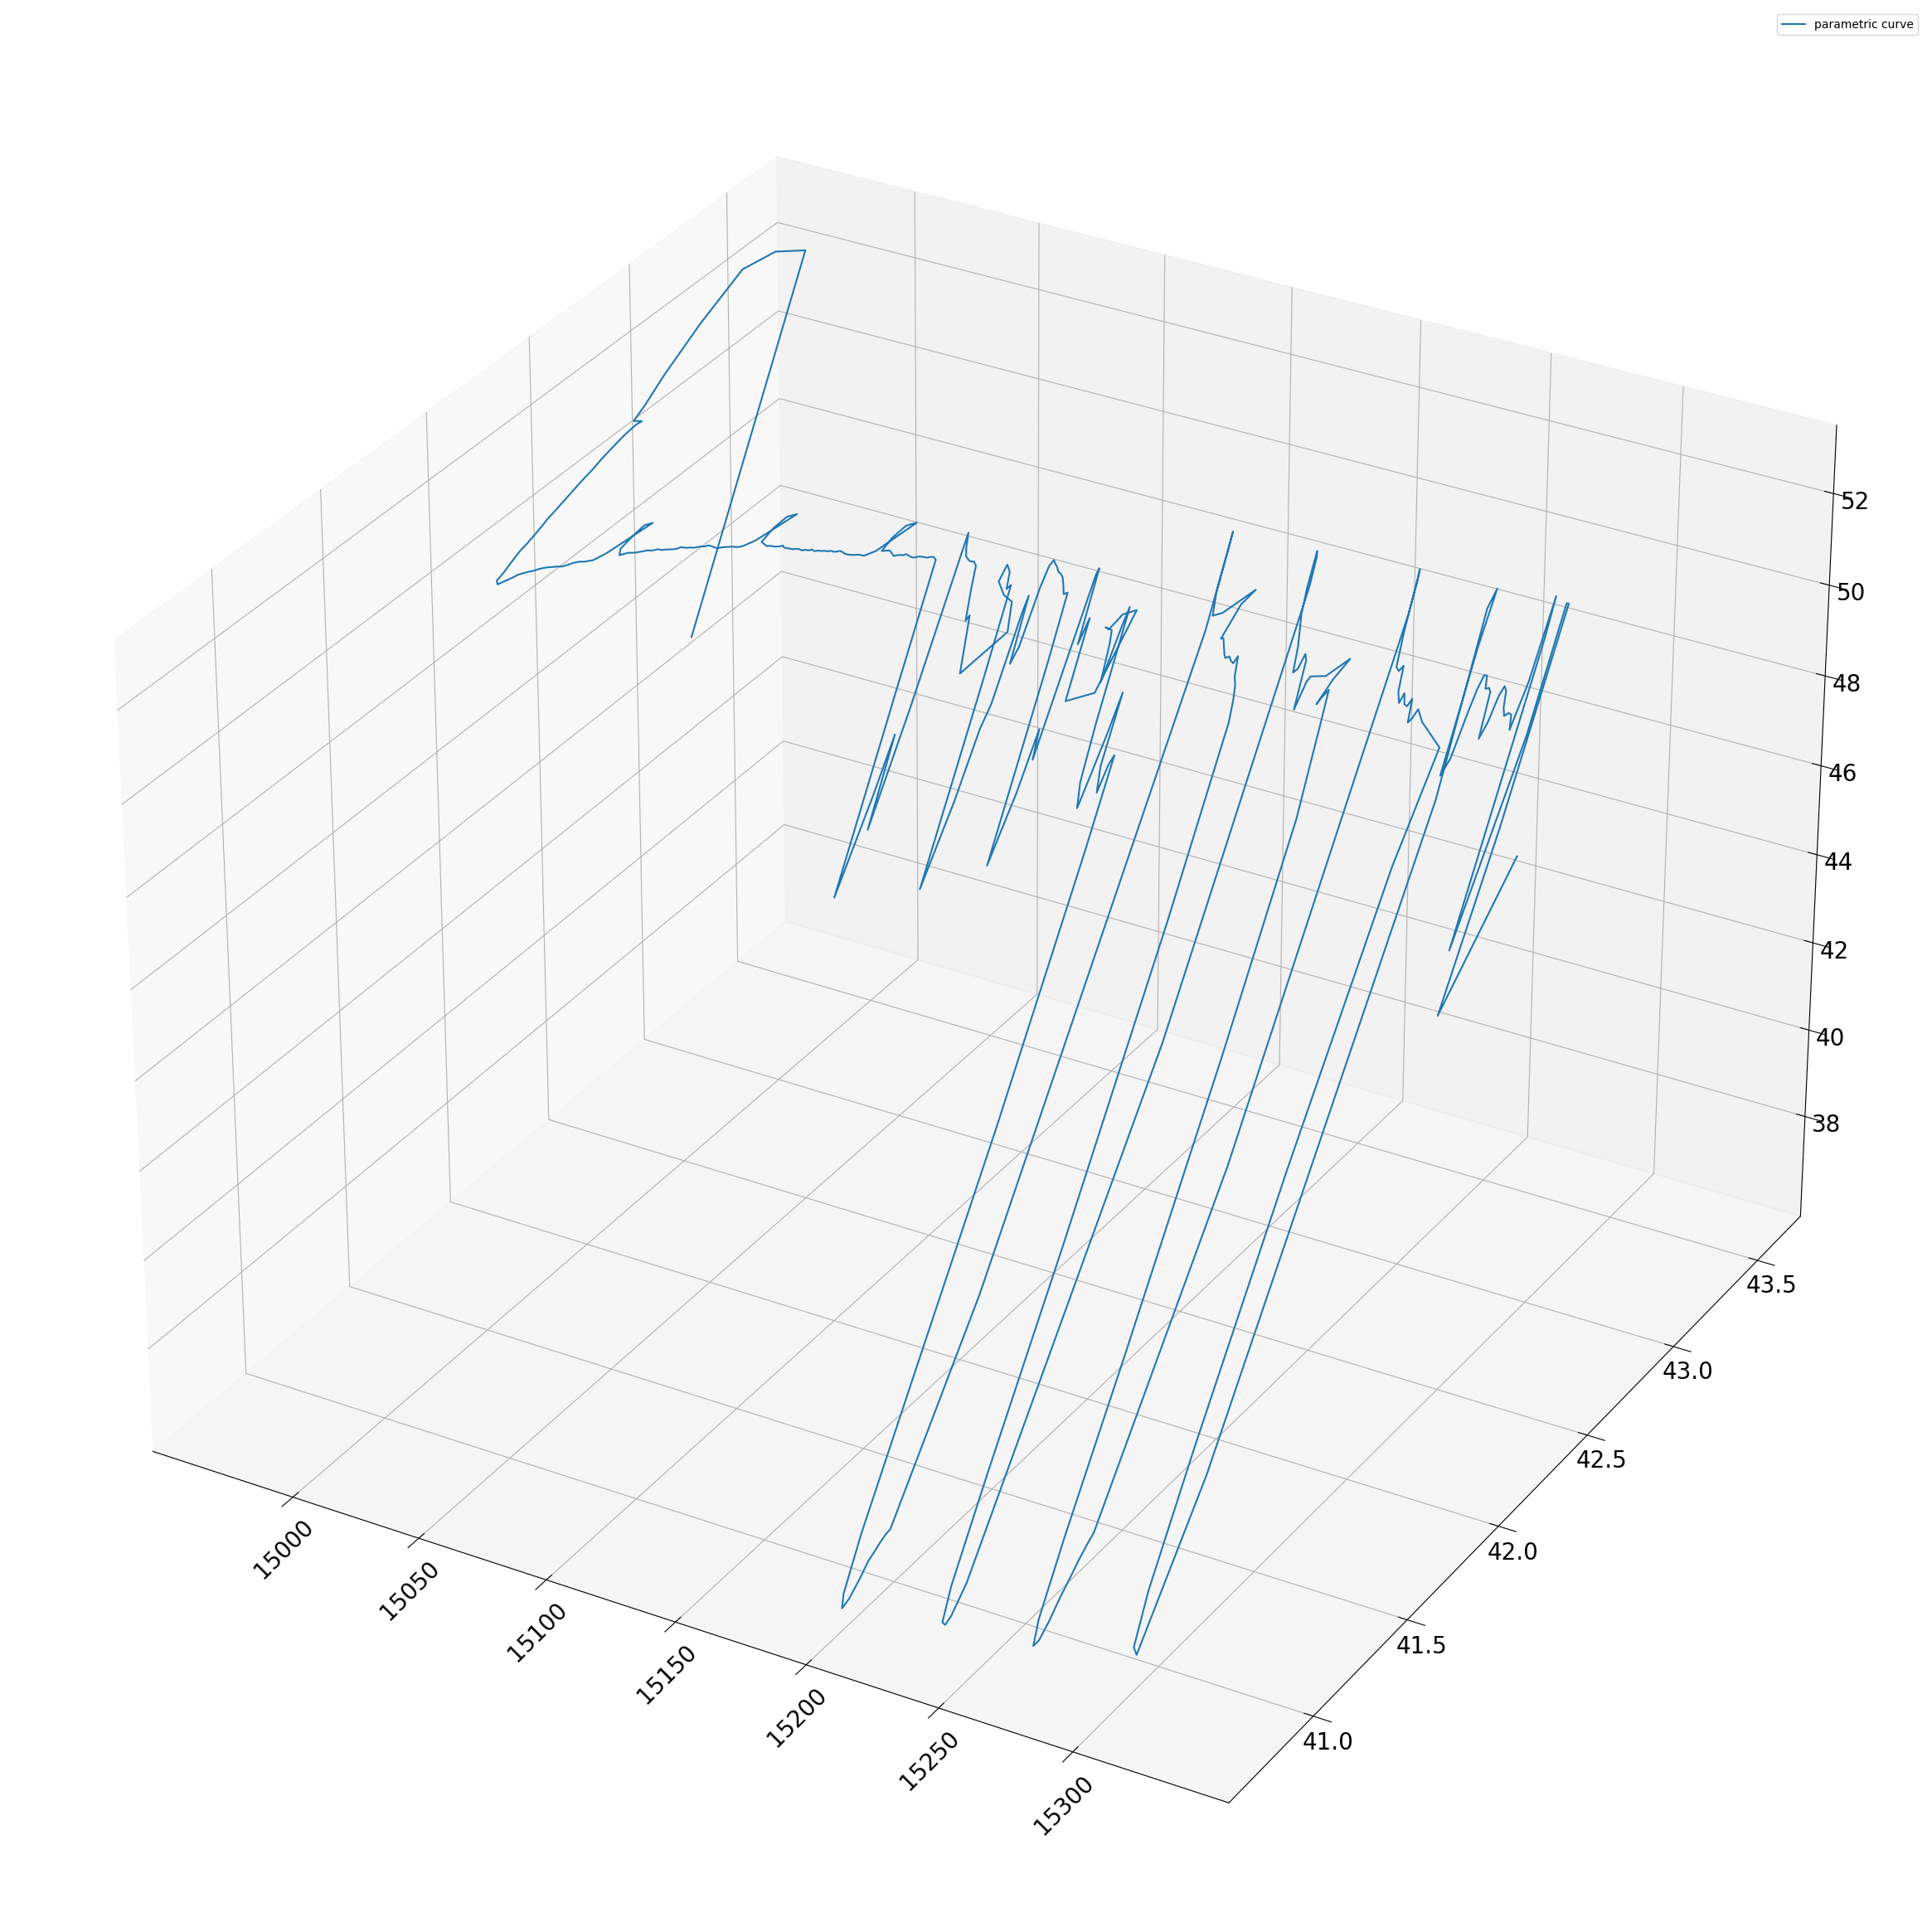

In [16]:
ax = plt.figure(figsize=(30, 30)).add_subplot(projection='3d')
ax.plot(steady_continuous_interval_slice["index"], 
        steady_continuous_interval_slice[U_stack], 
        steady_continuous_interval_slice[I_stack], label='parametric curve')
ax.legend()
ax.tick_params(axis = 'x', labelrotation = 45) 
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

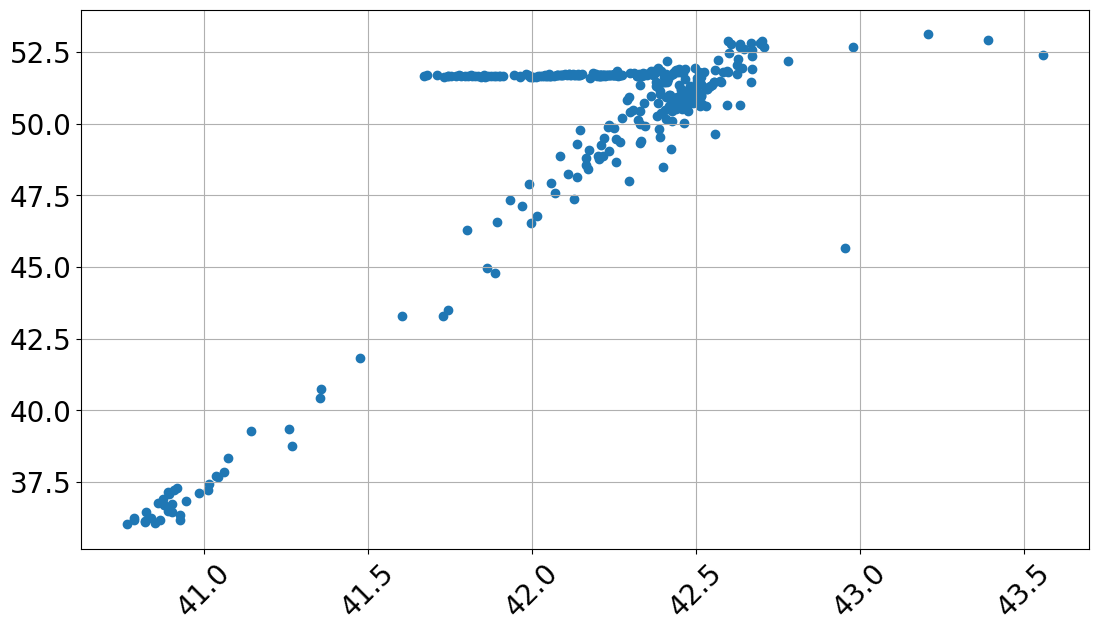

In [17]:
fig, ax = plt.subplots(figsize=(13, 7))
plt.scatter(steady_continuous_interval_slice[U_stack], steady_continuous_interval_slice[I_stack])
# plt.legend(prop={'size': 20})
plt.grid(visible=True)
ax.tick_params(axis = 'x', labelrotation = 45) 
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

In [18]:
sos = signal.butter(2, 1000, 'lp', fs=9000, output='sos')
filtered = signal.sosfilt(sos, steady_continuous_interval_slice[U_ctr])
filtered = signal.sosfilt(sos, filtered)

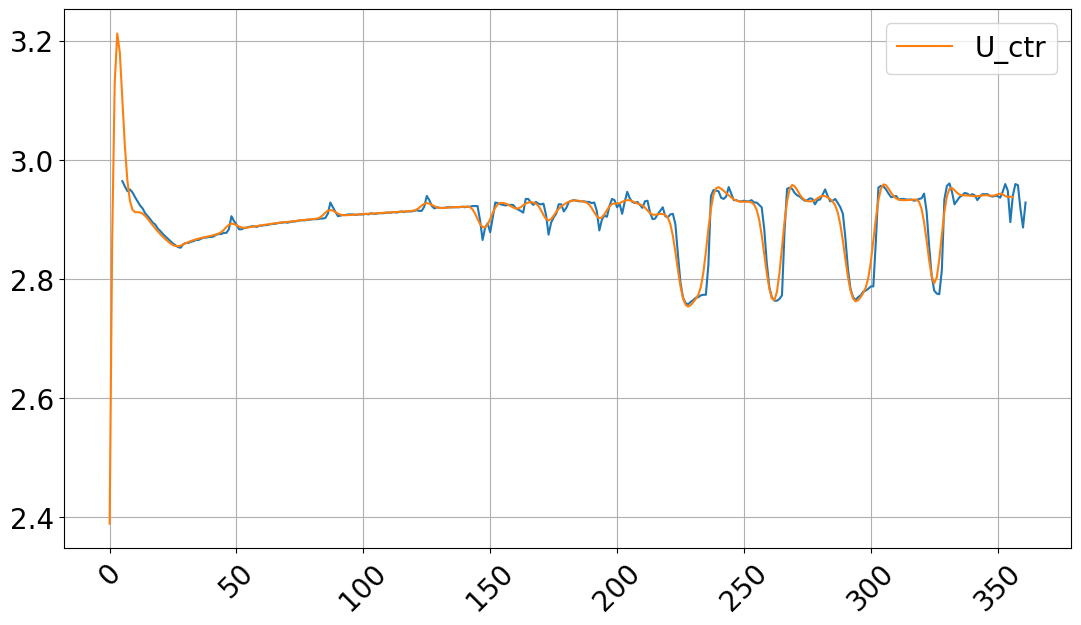

In [19]:
fig, ax = plt.subplots(figsize=(13, 7))
plt.plot(steady_continuous_interval_slice[U_ctr].reset_index().drop(columns=["index"])[5:])
plt.plot(filtered[5:], label='U_ctr')
plt.legend(prop={'size': 20})
plt.grid(visible=True)
ax.tick_params(axis = 'x', labelrotation = 45)
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

In [20]:
filtered_U = signal.sosfilt(sos, steady_continuous_interval_slice[U_stack])
filtered_U = signal.sosfilt(sos, filtered_U)

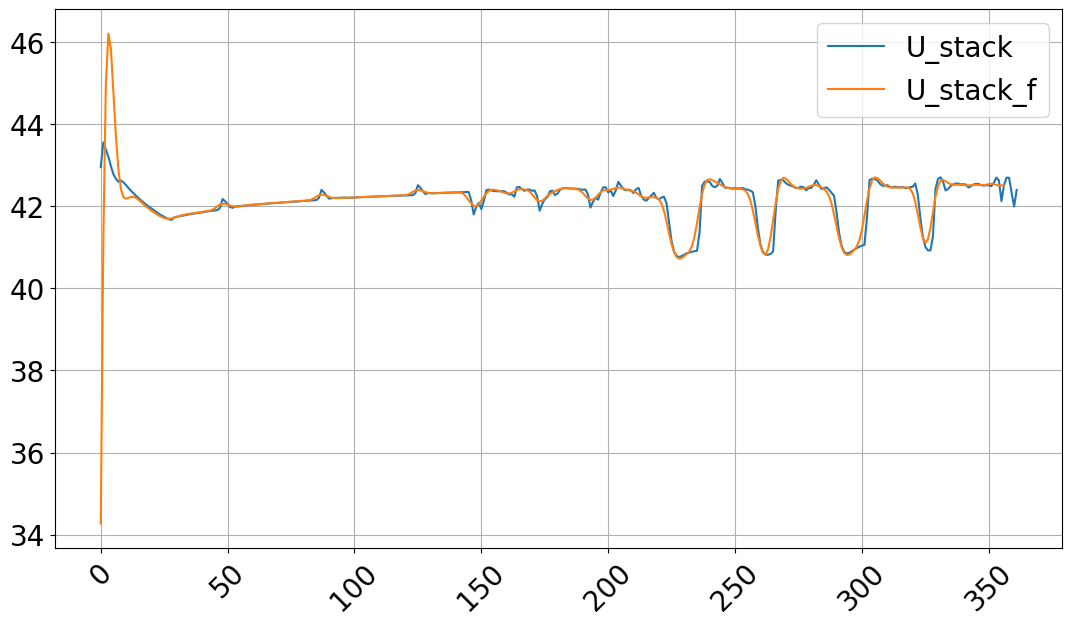

In [21]:
fig, ax = plt.subplots(figsize=(13, 7)) 
plt.plot(steady_continuous_interval_slice[U_stack].reset_index().drop(columns=["index"]), label='U_stack')
plt.plot(filtered_U[5:], label='U_stack_f')
plt.legend(prop={'size': 20})
plt.grid(visible=True)
ax.tick_params(axis = 'x', labelrotation = 45)
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

In [22]:
filtered_I = signal.sosfilt(sos, steady_continuous_interval_slice[I_stack])
filtered_I = signal.sosfilt(sos, filtered_I)

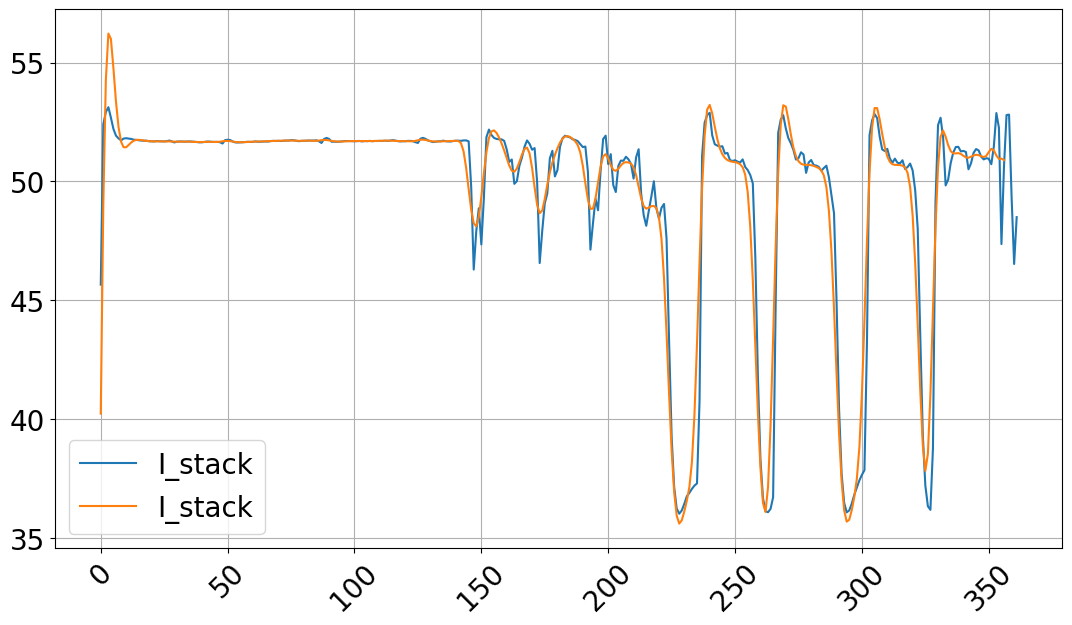

In [23]:
fig, ax = plt.subplots(figsize=(13, 7)) 
plt.plot(steady_continuous_interval_slice[I_stack].reset_index().drop(columns=["index"]), label='I_stack')
plt.plot(filtered_I[5:], label='I_stack')
plt.legend(prop={'size': 20})
plt.grid(visible=True)
ax.tick_params(axis = 'x', labelrotation = 45)
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

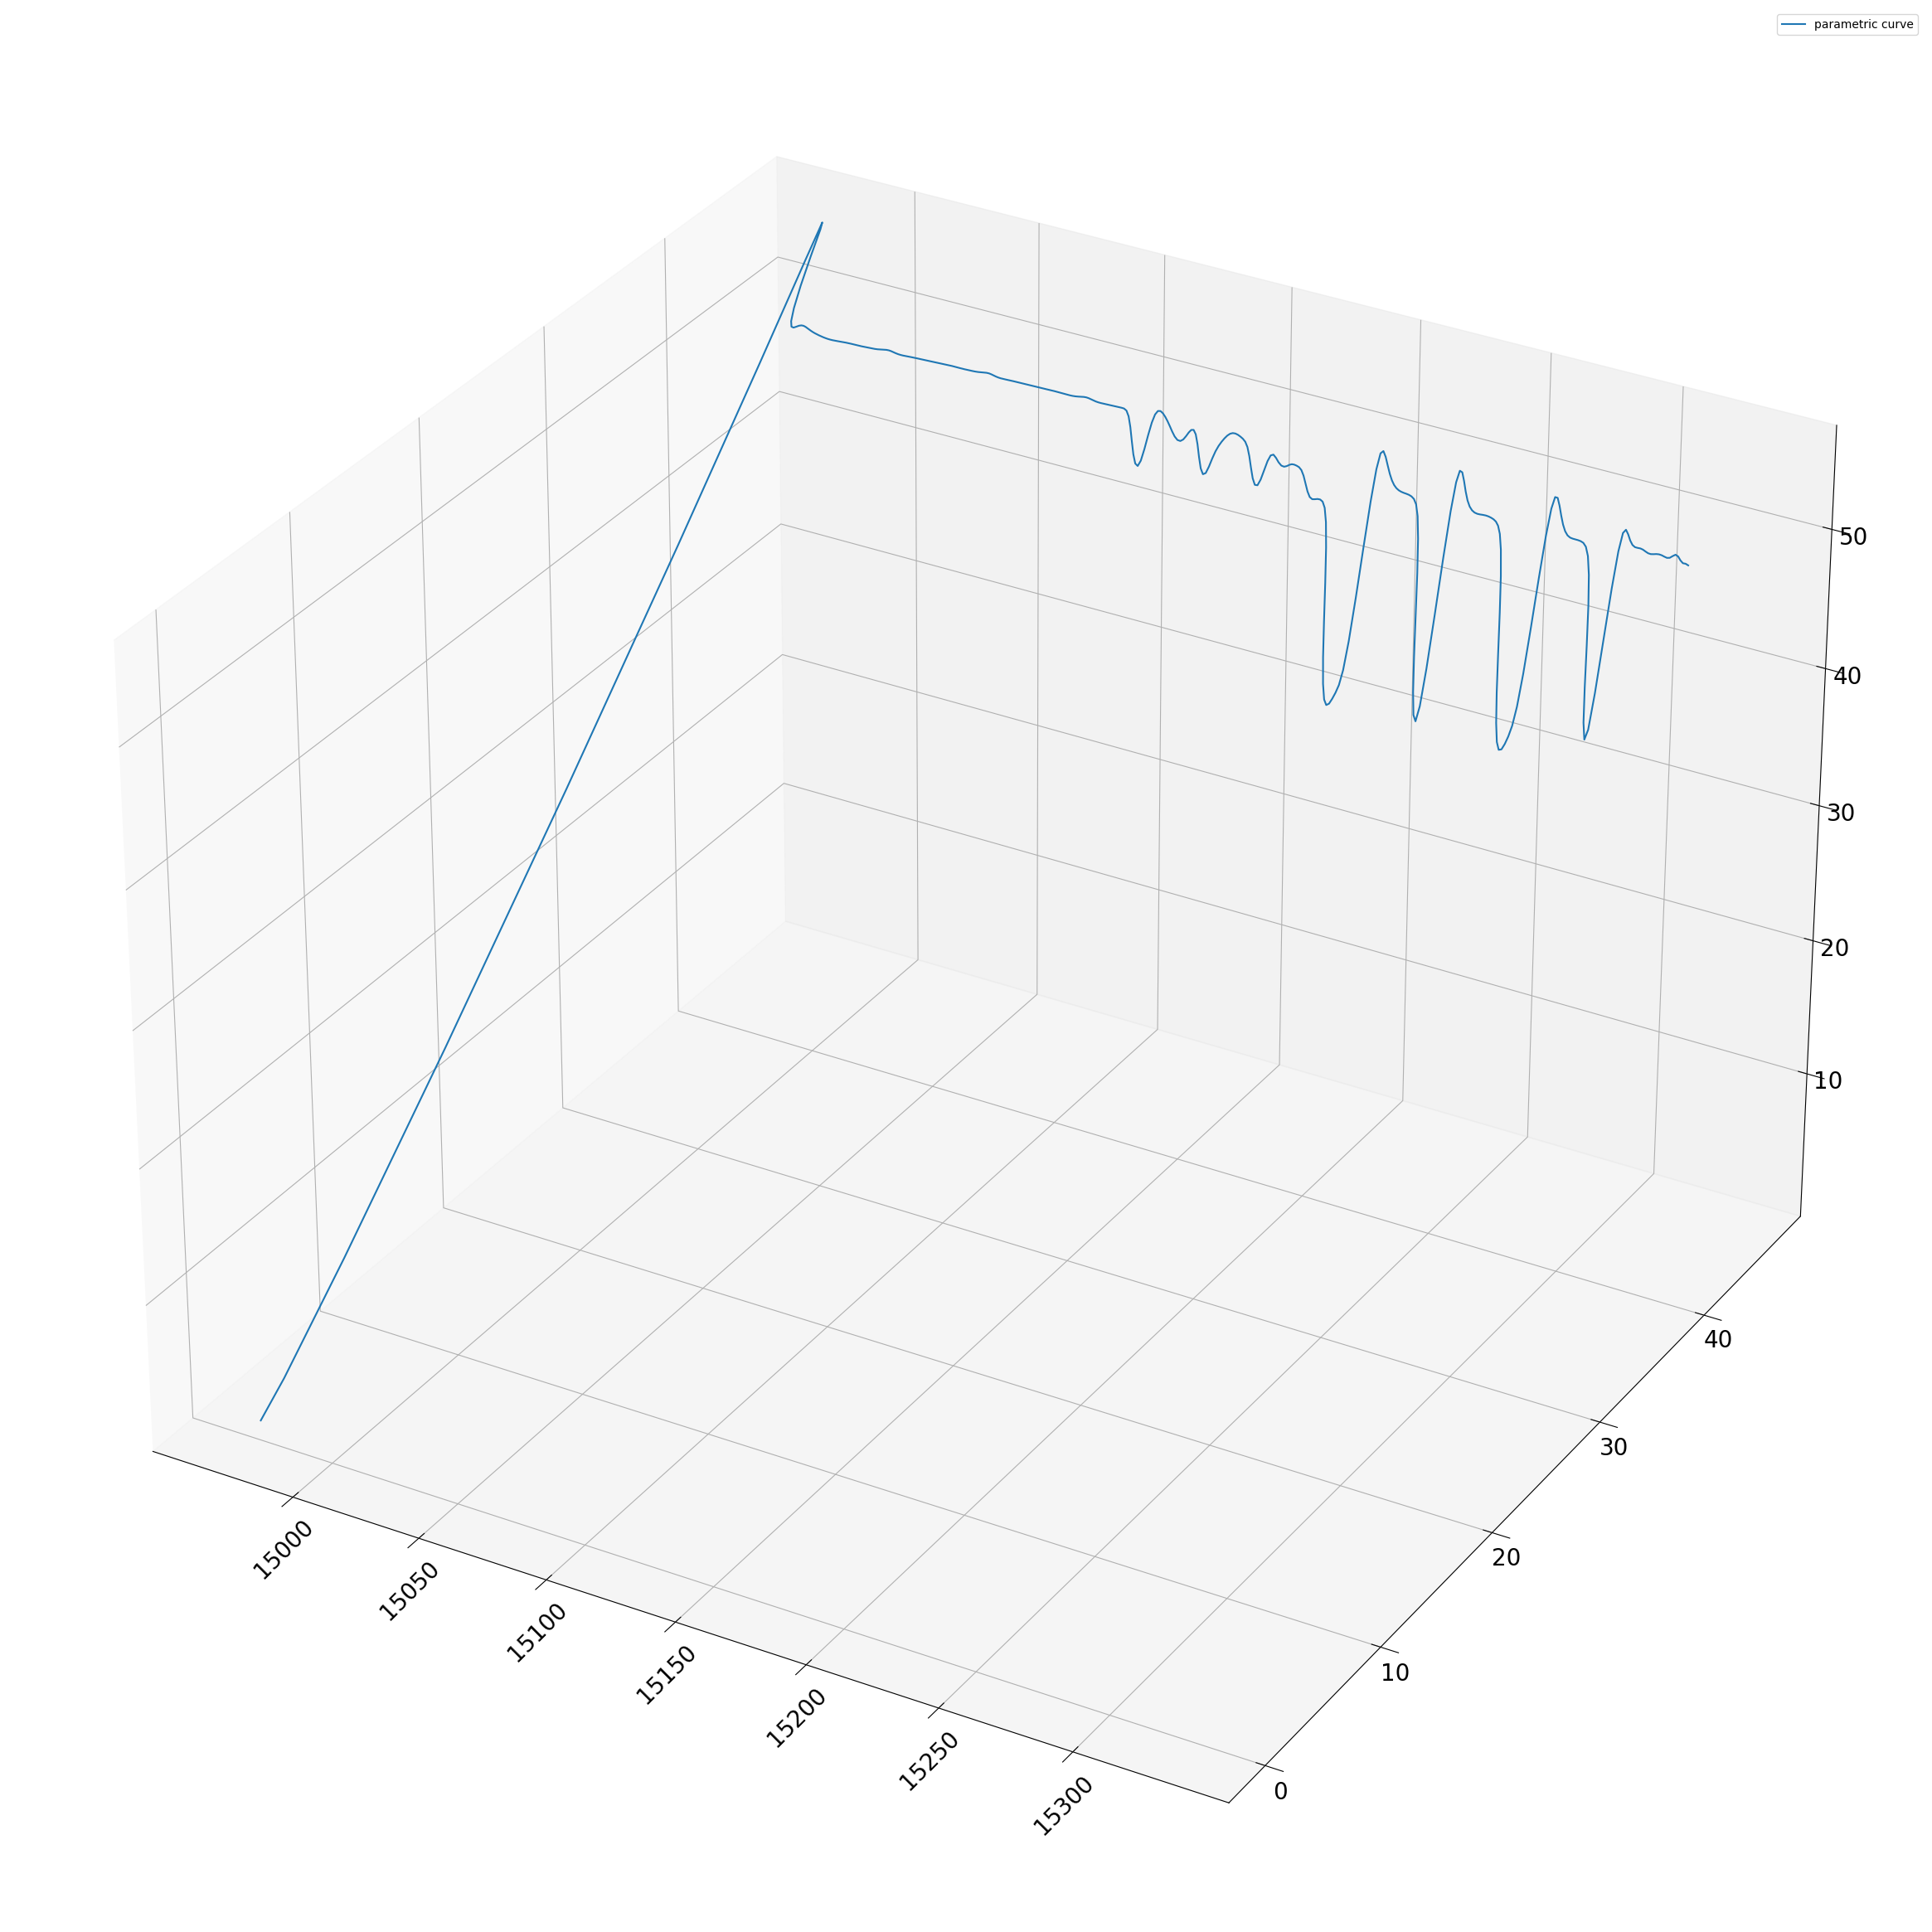

In [24]:
ax = plt.figure(figsize=(30, 30)).add_subplot(projection='3d')
ax.plot(steady_continuous_interval_slice["index"], 
        filtered_U, 
        filtered_I, label='parametric curve')
ax.legend()
ax.tick_params(axis = 'x', labelrotation = 45) 
ax.tick_params(axis = 'both', labelsize = 20)
plt.show()

In [28]:
inputs_outputs = pd.DataFrame()
inputs_outputs["inputs"] = filtered_U
inputs_outputs["outputs"] = filtered_I

In [31]:
inputs_outputs.to_csv("inputs_outputs.csv", index=False)

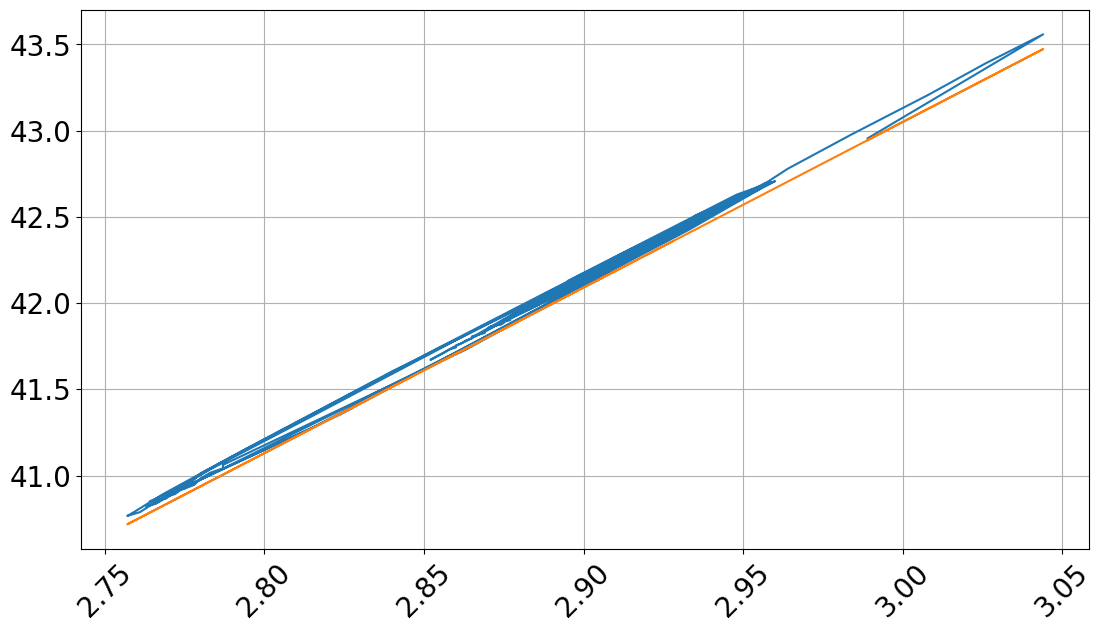

In [25]:
fig, ax = plt.subplots(figsize=(13, 7)) 
plt.plot(steady_continuous_interval_slice[U_ctr], steady_continuous_interval_slice[U_stack])
# line = 9.6 * np.ones(len(elec_df[U_ctr]))
plt.plot(steady_continuous_interval_slice[U_ctr], 9.6 * steady_continuous_interval_slice[U_ctr] + 14.25*np.ones(len(steady_continuous_interval_slice[U_ctr])))
# plt.legend(prop={'size': 20})
plt.grid(visible=True)
ax.tick_params(axis = 'x', labelrotation = 45) 
ax.tick_params(axis = 'both', labelsize = 20)
# ax.set_ylim(ymin=0)
# ax.set_xlim(xmin=0)
plt.show()